In [13]:
import pandas as pd
import numpy as np
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("diabetes_data_clean.csv")

In [18]:
# splitting X & y variables
features = [c for c in df.columns if c not in ("diabetes_class")]
X = df[features].values
y = df["diabetes_class"].values

In [17]:
# 10-fold cv evaluation

nb_model = BernoulliNB()
lr_model = LogisticRegression(penalty = "l2", solver = "lbfgs", max_iter = 1000, random_state = 42)

models = {"Naive Bayes (BernoulliNB)": nb_model, "Logistic Regression (L2)": lr_model}

print("\n" + "=" * 60)
print("Evaluation 1: 10-Fold CV")
print("=" * 60)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv = 10, scoring = "accuracy")
    y_pred_cv = cross_val_predict(model, X, y, cv = 10)
    cv_results[name] = {"scores": scores, "mean_acc": scores.mean(), "std_acc": scores.std(), "y_pred": y_pred_cv}
    print(f"\n {name}")
    print(f" Per-fold accuracies: {np.round(scores * 100, 1)}")
    print(f" Mean accuracy: {scores.mean() * 100: .1f}% (paper: NB = 87.4%, LR = 92.4%)")
    print(f" Standard deviation: ±{scores.std() * 100: .1f}%")
    print(f"\n Classification Report (aggregated over folds):")
    print(classification_report(y, y_pred_cv, target_names = ["Negative", "Positive"], digits = 3 ))
    


Evaluation 1: 10-Fold CV

 Naive Bayes (BernoulliNB)
 Per-fold accuracies: [78.8 88.5 82.7 92.3 82.7 86.5 86.5 94.2 88.5 90.4]
 Mean accuracy:  87.1% (paper: NB = 87.4%, LR = 92.4%)
 Standard deviation: ± 4.5%

 Classification Report (aggregated over folds):
              precision    recall  f1-score   support

    Negative      0.796     0.895     0.842       200
    Positive      0.929     0.856     0.891       320

    accuracy                          0.871       520
   macro avg      0.862     0.876     0.867       520
weighted avg      0.878     0.871     0.872       520


 Logistic Regression (L2)
 Per-fold accuracies: [ 86.5  94.2  98.1  92.3  82.7  92.3  94.2 100.   92.3  98.1]
 Mean accuracy:  93.1% (paper: NB = 87.4%, LR = 92.4%)
 Standard deviation: ± 5.0%

 Classification Report (aggregated over folds):
              precision    recall  f1-score   support

    Negative      0.898     0.925     0.911       200
    Positive      0.952     0.934     0.943       320

    ac

In [20]:
# percentage split evaluation 
print("=" * 60)
print("Evaluation 2: Percentage Split (80%/20%)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42, stratify = y)

print(f" Train size: {len(X_train)} | Test size: {len(X_test)}")

split_results = {}
for name,model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    split_results[name] = {"acc": acc, "y_pred": y_pred}
    print(f"\n {name}")
    print(f" Accuracy: {acc * 100: .1f}% (paper: NB = 88.0%, LR = 91.0%)")
    print(f"\n Classification Report:")
    print(classification_report(y_test, y_pred, target_names = ["Negative", "Positive"], digits = 3))

Evaluation 2: Percentage Split (80%/20%)
 Train size: 416 | Test size: 104

 Naive Bayes (BernoulliNB)
 Accuracy:  90.4% (paper: NB = 88.0%, LR = 91.0%)

 Classification Report:
              precision    recall  f1-score   support

    Negative      0.812     0.975     0.886        40
    Positive      0.982     0.859     0.917        64

    accuracy                          0.904       104
   macro avg      0.897     0.917     0.902       104
weighted avg      0.917     0.904     0.905       104


 Logistic Regression (L2)
 Accuracy:  94.2% (paper: NB = 88.0%, LR = 91.0%)

 Classification Report:
              precision    recall  f1-score   support

    Negative      0.886     0.975     0.929        40
    Positive      0.983     0.922     0.952        64

    accuracy                          0.942       104
   macro avg      0.935     0.948     0.940       104
weighted avg      0.946     0.942     0.943       104



In [24]:
# summary table
print("=" * 60)
print("Summary: Correctly / Incorrectly Classified Instances")
print("=" * 60)
header = f"{'Metric':<38} {'NB (CV)':>10} {'LR (CV)':>10} {'NB (Split)':>12} {'LR (Split)':>12}"
print(header)
print("-" * len(header))

nb_cv_corr = int(round(cv_results["Naive Bayes (BernoulliNB)"]["mean_acc"] * len(X)))
lr_cv_corr = int(round(cv_results["Logistic Regression (L2)"]["mean_acc"] * len(X)))
nb_sp_corr = int(round(split_results["Naive Bayes (BernoulliNB)"]["acc"] * len(X_test)))
lr_sp_corr = int(round(split_results["Logistic Regression (L2)"]["acc"] * len(X_test)))

total_cv, total_sp = len(X), len(X_test)
rows = [("Total Instances", total_cv, total_cv, total_sp, total_sp), 
        ("Correctly Classified", nb_cv_corr, lr_cv_corr, nb_sp_corr, lr_sp_corr), 
        ("Incorrectly Classified", total_cv - nb_cv_corr, total_cv - lr_cv_corr, total_sp - nb_sp_corr, total_sp - lr_sp_corr)]
for label, a, b, c, d in rows: 
    print(f" {label:<36} {a:>10} {b:>10} {c:>12} {d:>12}")

Summary: Correctly / Incorrectly Classified Instances
Metric                                    NB (CV)    LR (CV)   NB (Split)   LR (Split)
--------------------------------------------------------------------------------------
 Total Instances                             520        520          104          104
 Correctly Classified                        453        484           94           98
 Incorrectly Classified                       67         36           10            6


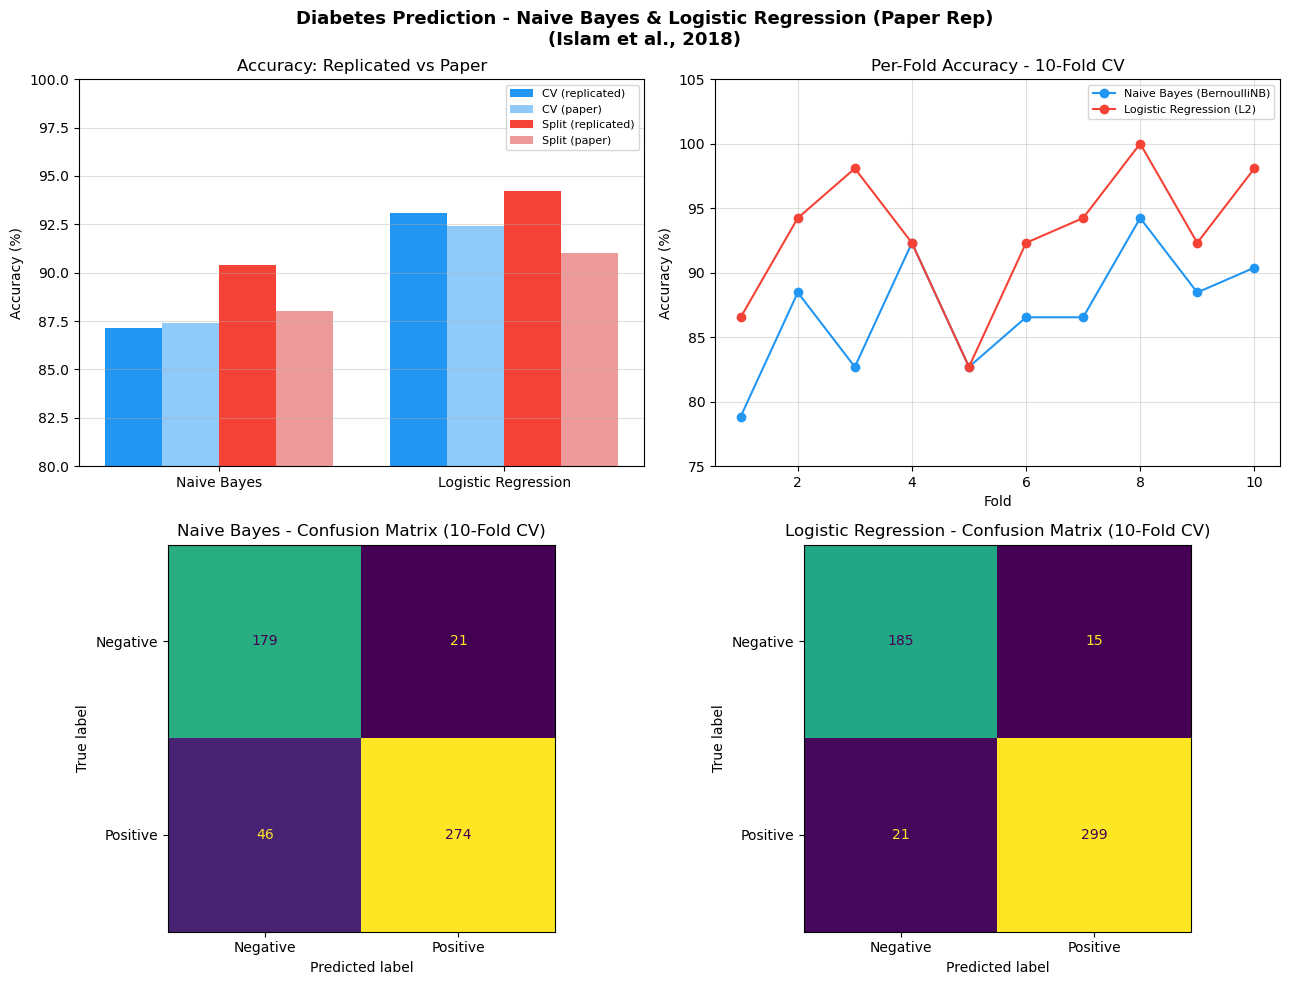

In [30]:
# plots
fig, axes = plt.subplots(2, 2, figsize = (13, 10))
fig.suptitle("Diabetes Prediction - Naive Bayes & Logistic Regression (Paper Rep)\n"
             "(Islam et al., 2018)",
             fontsize = 13, fontweight = "bold")

ax = axes[0, 0]
model_labels = ["Naive Bayes", "Logistic Regression"]
cv_accs = [cv_results[k]["mean_acc"] * 100 for k in models]
sp_accs = [split_results[k]["acc"] * 100 for k in models]
paper_cv = [87.4, 92.4]
paper_sp = [88.0, 91.0]

x = np.arange(len(model_labels))
w = 0.2
ax.bar(x - 1.5 * w, cv_accs, w, label = "CV (replicated)", color = "#2196F3")
ax.bar(x - 0.5 * w, paper_cv, w, label = "CV (paper)", color = "#90CAF9")
ax.bar(x + 0.5 * w, sp_accs, w, label = "Split (replicated)", color = "#F44336")
ax.bar(x + 1.5 * w, paper_sp, w, label = "Split (paper)", color = "#EF9A9A")
ax.set_xticks(x); ax.set_xticklabels(model_labels)
ax.set_ylim(80, 100); ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy: Replicated vs Paper")
ax.legend(fontsize = 8); ax.grid(axis = "y", alpha = 0.4)

ax = axes[0, 1]
folds = range(1, 11)
for name, color in [("Naive Bayes (BernoulliNB)", "#2196F3"), ("Logistic Regression (L2)", "#F44336")]:
    ax.plot(folds, cv_results[name]["scores"] * 100, marker = "o", label = name, color = color)
ax.set_xlabel("Fold"); ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Fold Accuracy - 10-Fold CV")
ax.legend(fontsize = 8); ax.grid(alpha = 0.4); ax.set_ylim(75, 105)

ax = axes[1, 0]
cm_nb = confusion_matrix(y, cv_results["Naive Bayes (BernoulliNB)"]["y_pred"])
ConfusionMatrixDisplay(cm_nb, display_labels=["Negative", "Positive"]).plot(ax = ax, colorbar = False)
ax.set_title("Naive Bayes - Confusion Matrix (10-Fold CV)")

ax = axes[1, 1]
cm_lr = confusion_matrix(y, cv_results["Logistic Regression (L2)"]["y_pred"])
ConfusionMatrixDisplay(cm_lr, display_labels = ["Negative", "Positive"]).plot(ax = ax, colorbar = False)
ax.set_title("Logistic Regression - Confusion Matrix (10-Fold CV)")

plt.tight_layout()
plt.savefig("diabetes_rep_results.png", dpi = 150, bbox_inches = "tight")
plt.show()

In [31]:
lr_final = LogisticRegression(penalty = "l2", solver = "lbfgs", max_iter = 1000, random_state = 42)
lr_final.fit(X, y)
coeff_df = pd.DataFrame({"Feature": features, "Coefficient": lr_final.coef_[0]}).sort_values("Coefficient", ascending = False)

print("\n" + "=" * 60)
print("Logistic Regression Coefficients (trained ou full dataset)")
print("=" * 60)
print(coeff_df.to_string(index = False))


Logistic Regression Coefficients (trained ou full dataset)
           Feature  Coefficient
        polydipsia     2.973728
          polyuria     2.778817
      irritability     1.562805
    genital_thrush     1.160908
   partial_paresis     0.901782
        polyphagia     0.714734
sudden_weight_loss     0.548979
   visual_blurring     0.530220
          weakness     0.458723
          alopecia    -0.123409
           obesity    -0.139666
  muscle_stiffness    -0.330351
        age_scaled    -0.347019
   delayed_healing    -0.432809
           itching    -1.396243
            gender    -2.755051
